# Modeling — Understanding the World Through Data

## Purpose

Now that we had finished buidling our database [pipeline](https://github.com/dcnguyen060899/su_cpsc5071_group_project_sad_sravya_anushka_duy/blob/main/code/database_pipeline.ipynb) and completed our [exploratory data analysis](https://github.com/dcnguyen060899/su_cpsc5071_group_project_sad_sravya_anushka_duy/blob/main/code/eda.ipynb). This notebook will help us build statisitcal models to answer the questions our EDA raised:
1. Which county-level characteristics are statisitically associated with disaster frequency? Do demographic like poverty and unemployment predict disasters, or is geography the dominant driver? 
    - Note that these two questions are hypothesized from our EDA process that we expect geography preodict disaster, but we getting ahead of ourself. We need to first prove it through modeling.
2. Can we classify counties as high-impact vs. low-impact using only socioeconomic and housing features?
3. How much explanatory power does geography add beyond demographics alone?

For this modeling study, our aim is to be able to interpret semi complex model. What we meant by semi is that it is not a black box like deep learning model that uses multi layer perceptron. Therefore, our plan is to build three models: OLS regression, logistic regression and a decision tree. Again, we chosen not for maximum predictive power but for transparency and pedagogical value. We anticipate that each model will teach us something different about the data. Also, we believe that this is a data management course for data science and not a statistical machine learning course, therefore, we feel that the goal is to demonstrate that a well designed data pipeline produces a dataset that supports meaningful statistical analysis. That being said, the models are a tools for understanding, not an end in themselves.


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# modeling libraries we need for OLS regression, logistic regression and decision tree
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
)

# plot styling (this is the same setup as EDA notebook)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Locally please load from MySQL Workbench or MySQL Docker container using SQLAlchemy and mysql-connector-python
# PLEASE: remember to use password with your own MySQL password and not mine!
config = {
    'host': 'localhost', # this is not your host, please use your own host for your local MySQL instance (e.g., localhost or 127.0.0.1)
    'user': 'root', # this is not your username, please use your own username for your local MySQL instance (e.g., root or admin or whatever you namded your MySQL user)
    'password': 'cpsc5071', # this is not your password, please use your own password for your local MySQL instance
    'port': 3306, # this is not your port, please use your own port for your local MySQL instance (e.g., 3306 or whatever you mapped in your Docker container)
    'database': 'disaster_impact_db' # this is our database name, you can keep it the same or change it in the database pipeline
     # if you want but make sure to update it here and in your MySQL instance accordingly
}

engine = create_engine(
    f"mysql+mysqlconnector://{config['user']}:{config['password']}@{config['host']}:{config['port']}/{config['database']}"
)

# print out some basic info to confirm connection and data access to your local machine's MySQL Docker container
# it a good practice to run some basic queries to confirm the connection
# and data access before running more complex queries or loading large datasets into pandas
with engine.connect() as conn:
    result = conn.execute(text("SELECT VERSION()"))
    print(f"MySQL Version: {result.scalar()}")

    result = conn.execute(text("SELECT DATABASE()"))
    print(f"Connected to DB: {result.scalar()}")

    result = conn.execute(text("SELECT COUNT(*) FROM analysis_ready"))
    print(f"Rows in analysis_ready: {result.scalar()}")

print("\nConnection successful - running against local MySQL Docker container. \n")

df = pd.read_sql('SELECT * FROM analysis_ready', engine)
engine.dispose() # it is a good pracetice to dispose the engine after use to free up resources

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

MySQL Version: 8.0.44
Connected to DB: disaster_impact_db
Rows in analysis_ready: 3292

Connection successful - running against local MySQL Docker container. 

Shape: (3292, 17)
Columns: ['fips', 'county_name', 'state_abbr', 'total_disasters', 'ia_count', 'pa_count', 'total_population', 'median_household_income', 'poverty_count', 'unemployment_count', 'labor_force_count', 'fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4', 'metro']


,fips,county_name,state_abbr,total_disasters,ia_count,pa_count,total_population,median_household_income,poverty_count,unemployment_count,labor_force_count,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4,metro
0,01000,Unknown,AL,7,0.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01001,"Autauga County, Alabama",AL,6,0.0,6.0,58761.0,68315.0,6630.0,752.0,27163.0,848.0,888.0,1055.0,1345.0,1665.0,1.0
2,01003,"Baldwin County, Alabama",AL,5,0.0,5.0,233420.0,71039.0,23445.0,3825.0,111079.0,972.0,1043.0,1244.0,1550.0,1975.0,1.0
3,01005,"Barbour County, Alabama",AL,7,0.0,7.0,24877.0,39712.0,5280.0,516.0,8968.0,587.0,648.0,772.0,996.0,1027.0,0.0
4,01007,"Bibb County, Alabama",AL,5,0.0,5.0,22251.0,50669.0,4297.0,786.0,9028.0,998.0,1144.0,1267.0,1583.0,1791.0,1.0




## 2. Data Preparation for Modeling
### Feature Engineering (we need to transform similar to EDA)

In [2]:

# first we convert raw counts to per-capita rates so counties of different sizes are comparable
df['poverty_rate'] = np.where(
    df['total_population'] > 0,
    df['poverty_count'] / df['total_population'] * 100,
    np.nan
)

df['unemployment_rate'] = np.where(
    df['labor_force_count'] > 0,
    df['unemployment_count'] / df['labor_force_count'] * 100,
    np.nan
)

# implement log population as population spans several orders of magnitude (50 to 10M)
df['log_population'] = np.log1p(df['total_population'])

print('Engineered features created: poverty_rate, unemployment_rate, log_population')
print(df[['poverty_rate', 'unemployment_rate', 'log_population']].describe().round(2))

Engineered features created: poverty_rate, unemployment_rate, log_population
       poverty_rate  unemployment_rate  log_population
count       3222.00            3222.00         3222.00
mean          14.57               5.16           10.27
std            7.50               2.93            1.50
min            1.60               0.00            3.93
25%            9.83               3.44            9.31
50%           13.09               4.72           10.16
75%           17.19               6.14           11.12
max           65.57              31.99           16.11


### Listwise delete (using .dropna() from pandas)

As we diagnose in EDA thoroughly, there are still 80 missing rows despite after we left join with clean database deisgn (for information preservation). We need our "cleaned" database to be even more clean for modeling to work because these model can't processing missing value.

In [3]:
# remember back in EDA: 80 rows have at least one NULL (coverage gaps across
# Census, HUD, and FEMA datasets). These are not random as they are US territories,
# Alaska non-standard jurisdictions, and Connecticut's restructured counties.

# define our feature columns and target column
feature_cols = ['log_population', 'median_household_income', 'poverty_rate',
                'unemployment_rate', 'fmr_2', 'metro']

cols_needed = feature_cols + ['total_disasters', 'state_abbr']

df_model = df[cols_needed].dropna().copy()

print(f'Rows before dropping NULLs: {len(df)}')
print(f'Rows after dropping NULLs:  {len(df_model)}')
print(f'Rows dropped: {len(df) - len(df_model)} ({(len(df) - len(df_model))/len(df)*100:.1f}%)')
print(f'\nNull check after drop:')
print(df_model.isnull().sum().to_string())

Rows before dropping NULLs: 3292
Rows after dropping NULLs:  3212
Rows dropped: 80 (2.4%)

Null check after drop:
log_population             0
median_household_income    0
poverty_rate               0
unemployment_rate          0
fmr_2                      0
metro                      0
total_disasters            0
state_abbr                 0


### Creating target variables
Perfect, now, our data are ready for modeling. But first, remember that back in eda, there is a right skew for total_disaster. So what do I do for modeling to be interpreble? We log them such that it would reduces the right skew.

In [5]:

# Regression target: log(1 + total_disasters)
# log transform reduces right skew identified in EDA and makes OLS assumptions more reasonable
df_model['log_disasters'] = np.log1p(df_model['total_disasters'])

# Classification target: high_impact = 1 if total_disasters > median, else 0
median_threshold = df_model['total_disasters'].median()
df_model['high_impact'] = (df_model['total_disasters'] > median_threshold).astype(int)

print(f'Regression target — log_disasters:')
print(df_model['log_disasters'].describe().round(3))

print(f'\nClassification target — high_impact (threshold: > {median_threshold:.0f} disasters):')
print(df_model['high_impact'].value_counts())
print(f'Class balance: {df_model["high_impact"].mean()*100:.1f}% high-impact')

Regression target — log_disasters:
count    3212.000
mean        1.736
std         0.496
min         0.000
25%         1.386
50%         1.609
75%         2.079
max         5.011
Name: log_disasters, dtype: float64

Classification target — high_impact (threshold: > 4 disasters):
high_impact
0    1641
1    1571
Name: count, dtype: int64
Class balance: 48.9% high-impact


As we expected, the regression target log_disaster is well behaved after we log tranform them. With most counties we observe clustered around 3 to 7 disasters and we further expected its a nearly symetric distribution that is suitable for OLS. The classification target is nearly perfectly balanced at 48.9 percent with high impact counties (couties that has more than 4 disasters). Bottom line is that our models can be evaluated striaghtforwardly without any class imblance corrections.



## 3. Train/Test Split

We need to split our dataset into training set and test set. Typically, we want our train set to have more data so that it can learn more pattern and hopefully it can generalize such that it would also have a low training curve for test set as well.

One thing to notice for this part, remember that for 48.9 percent of high impact class ratio, when spliting into train and test set, ensure that it stratify equally; because without it, random chance could put a disproportionate number of high impact counties in one split, that would make our evaluation misleading, basically unrealiable. This is a basically sampling technique protocol we learn from statistical and experimental design course we learn last quarter DATA 5300.

In [7]:
# 80/20 train-test split
# important to stratify on the classification target so both train and test sets have
# roughly the same proportion of high-impact vs. low-impact counties.

X = df_model[feature_cols]
y_reg = df_model['log_disasters']       # regression target
y_cls = df_model['high_impact']          # classification target

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls  # ensures class balance is preserved in both splits
)

print(f'Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nClass balance in train: {y_cls_train.mean()*100:.1f}% high-impact')
print(f'Class balance in test:  {y_cls_test.mean()*100:.1f}% high-impact')
print(f'\nFeatures ({len(feature_cols)}): {feature_cols}')

Training set: 2569 rows (80%)
Test set:     643 rows (20%)

Class balance in train: 48.9% high-impact
Class balance in test:  48.8% high-impact

Features (6): ['log_population', 'median_household_income', 'poverty_rate', 'unemployment_rate', 'fmr_2', 'metro']


Cool, the 80/20 train/test split showed us that there are 2569 training and 643 test counties. As you can see, with stratify, the high impact class proportion nearly identical in both sets (48.9 percent and 48.9 percent), confirming 5 that stratification worked as intended. This further imply that any future performance differences between train and test is due to genuine generalization and not a skewd class distribution in either split or matter of fact, random chance. We are control these statistical uncertainty, our main purpose of this study!

## 4. Feature Scaling
Now leading up to our train test split, from EDA, we know that our median_household_income is in ten of thousands. What this means is that if we don't scale this, our modeling would learn some proportional of the data to be numerically dominate in other features like metro (binary 0/1) or poverty_rate(0-65). So when we run a logistic regression for example, its coefficients and regularization penalties are sensitive to those feature that are numerically dominant like median_household_income without fair scaling across features. Therefore, in this part, we want to use StandardScaler to puts all features on the same zero-mean, unit-variance scale so that model evaluates each feature on equal footing.

In [9]:
# this converts each feature to zero mean and unit variance.
# Critical: we fit ONLY on training data to prevent data leakage; and transform for test only, no fit
# If we fit on the full dataset, the scaler would "see" test set statistics,
# giving the model information it shouldn't have during training.

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),  # fit + transform on train
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),        # transform only on test (using train's mean/std)
    columns=feature_cols,
    index=X_test.index
)

print('Scaling parameters (learned from training data only):')
scale_params = pd.DataFrame({
    'mean': scaler.mean_,
    'std': scaler.scale_
}, index=feature_cols).round(3)
print(scale_params)

print(f'\nTrain scaled — mean ~ 0, std ~ 1:')
print(X_train_scaled.describe().round(3).loc[['mean', 'std']])

Scaling parameters (learned from training data only):
                              mean        std
log_population              10.277      1.496
median_household_income  62305.540  17408.932
poverty_rate                14.501      7.372
unemployment_rate            5.117      2.842
fmr_2                     1117.128    369.213
metro                        0.387      0.487

Train scaled — mean ~ 0, std ~ 1:
      log_population  median_household_income  poverty_rate  \
mean             0.0                      0.0          -0.0   
std              1.0                      1.0           1.0   

      unemployment_rate  fmr_2  metro  
mean               -0.0    0.0    0.0  
std                 1.0    1.0    1.0  


As you can see, the scaler learned each features mean and standard deviation only from the training data. The median_household_income had a mean of $62306 with a wide spread away from its mean ($17409 std). Comparing numerically to metro, since it is binary, we get 38.7 percent ofcounties in the training set are classified as metro/urban. So there is a clear mismatched numerically that would be hard for model to learn. Bottom line is that they are not scale proportionally. So after scaling, there mean are centered around zero with unit variance.


## 5. Model 1: OLS Linear Regression


Now that our features are scaled, we can confidently move on to our first model. 

In [11]:
# our group decided to use statsmodels (not sklearn) because it provides a full statistical summary:
# p-values for each coefficient, R-squared, F-statistic, confidence intervals.
# sklearn's LinearRegression only gives coefficients and R² — not enough for inference.

# add constant (intercept), as we check its documentation, statsmodels does not add one automatically
X_train_ols = sm.add_constant(X_train_scaled)
X_test_ols = sm.add_constant(X_test_scaled)

# fit OLS model
ols_model = sm.OLS(y_reg_train, X_train_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_disasters   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     82.57
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           9.82e-95
Time:                        10:30:46   Log-Likelihood:                -1636.1
No. Observations:                2569   AIC:                             3286.
Df Residuals:                    2562   BIC:                             3327.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Not to our surprised, the OLS model explains only 16.2 percent of the variance in log-disaster counts (as we see with R squared = 0.162). This confirmed us the fact that demographics alone are  a weak predictors of disaster frequency. On the other hand, we see that fmr_2 (which is the fair market rent) and poverty rate has a positive coefficient (keep in mind, however, very small p value and also it is coefficient not rho therefore it is a partial effect) increasing the disaster likelihood, however, higher income reduces it, the unemployment and metro status are not statistically significant. This further tells us that geography might be more impactful in modelling pattern for predicting disaster frequency. 

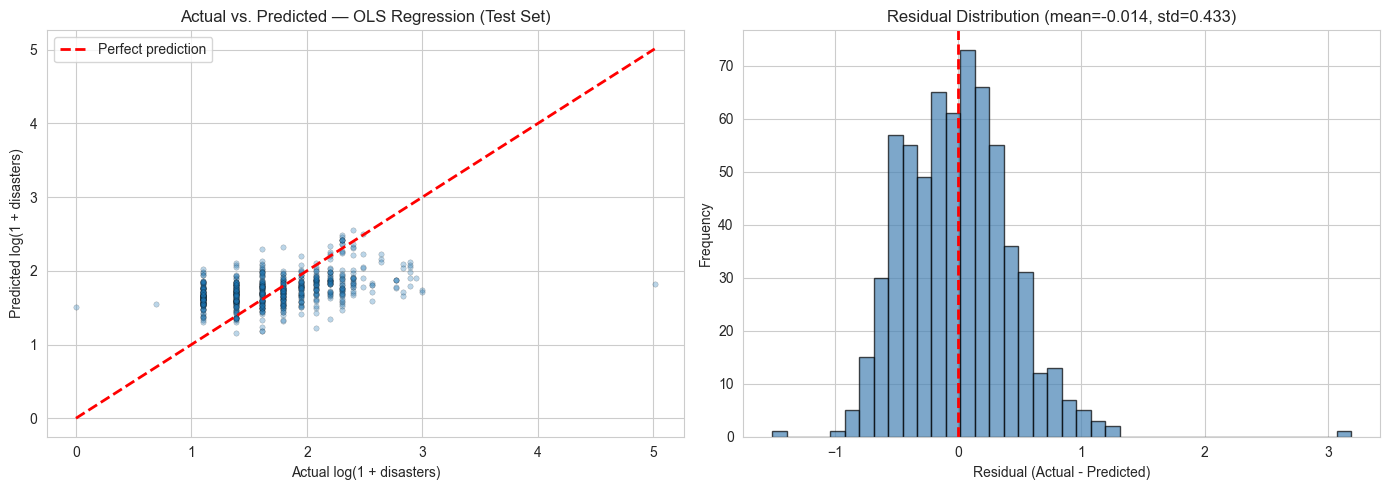

R² on training set: 0.1620
R² on test set:     0.1846


In [13]:

# predictions on test set
y_reg_pred = ols_model.predict(X_test_ols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# actual vs predicted
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=15, edgecolors='black', linewidths=0.3)
min_val = min(y_reg_test.min(), y_reg_pred.min())
max_val = max(y_reg_test.max(), y_reg_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual log(1 + disasters)')
axes[0].set_ylabel('Predicted log(1 + disasters)')
axes[0].set_title('Actual vs. Predicted — OLS Regression (Test Set)')
axes[0].legend()

# let print out residual distribution so we can see how error behaves across the test set. 
# Ideally, we want residuals to be symmetrically distributed around zero with no extreme outliers, 
# which would indicate that our model is capturing the underlying pattern well and not systematically over or under predicting.
residuals = y_reg_test - y_reg_pred
axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (mean={residuals.mean():.3f}, std={residuals.std():.3f})')

plt.tight_layout()
plt.show()

# printing out the R² on test set
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_reg_test - y_reg_test.mean())**2)
r2_test = 1 - ss_res / ss_tot
print(f'R² on training set: {ols_model.rsquared:.4f}')
print(f'R² on test set:     {r2_test:.4f}')

The model prediction, as we can see, is clustering in a narrow band, around 1.5 to 2.0 regardless of the actual value (remember this is log), implying that it fails to capture high disaster counties and right skewed residuals confirm us that it systematically underpredict for most disaster prone counties. This consistent with our finding that geography, not demographics that drives extreme disaster counts.

To further confirm this intuitively, remember, back in EDA, we showed that extreme disaster counties are concentrated in a specific hazard geography such as Gulf Coast hurricanes, tornado valley, some wildlife regions. 






## 6. Model 2: Logistic Regression

Now that we see OLS showed that demographics can't precisely explain quanitfy disaster counts as we observe in R square of 0.162. This means that there are 84 percent of the varance is unexplained by the model. Predictions is unrealiable with OLS model and its feature beaing used.

However, note that it is not completely useless, it just means that we should ask a simpler, more achievable question, can we at least classify which counties are more disaster prone than others instead of put full our faith demographically?

So natural, we would think of something like logistic regression, such that we can reframes the problem from predicting exactly how many disaster to more like how can we predict whether a county is above or below the median for example. This binary of yes and no allowed us to be honest with the demographic being a weak signal. Though we knowledge this fact, understand that demographic can still carry some sort of signal that can be enough to seperate high risk from low risk counties. So move from regression to classification is a pedagogical intellect to lower our ambition to match what we believe the data can actually support!

In [16]:
# predicting high_impact (above-median disaster count) from scaled features.
# Logistic regression is a natural starting point for binary classification because hopefuly we can do three things that OLS could not:
# 1. Coefficients are interpretable (log-odds ratios)
# 2. It provides probability estimates, not just labels
# 3. It makes few assumptions about feature distributions

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_cls_train)

# predictions
y_cls_pred = log_reg.predict(X_test_scaled)
y_cls_prob = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of high_impact = 1

print('Classification Report (Test Set)')
print(classification_report(y_cls_test, y_cls_pred, target_names=['Low Impact', 'High Impact']))

print(f'Accuracy:  {accuracy_score(y_cls_test, y_cls_pred):.3f}')
print(f'AUC-ROC:   {roc_auc_score(y_cls_test, y_cls_prob):.3f}')

Classification Report (Test Set)
              precision    recall  f1-score   support

  Low Impact       0.66      0.68      0.67       329
 High Impact       0.65      0.63      0.64       314

    accuracy                           0.66       643
   macro avg       0.66      0.66      0.66       643
weighted avg       0.66      0.66      0.66       643

Accuracy:  0.656
AUC-ROC:   0.711


### Let visualized the ROC Curve

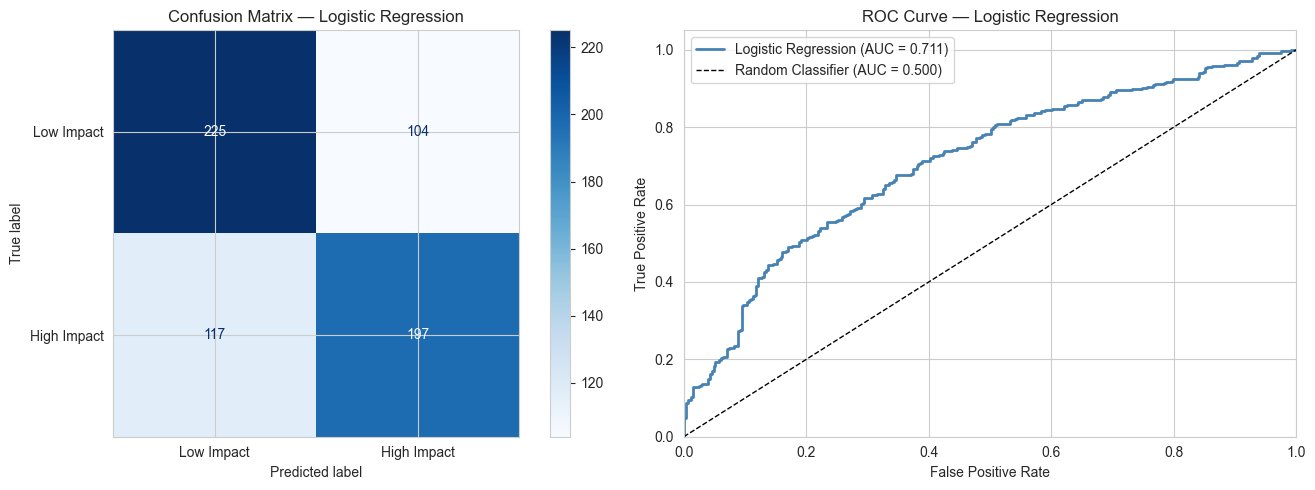

In [17]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix
cm = confusion_matrix(y_cls_test, y_cls_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Impact', 'High Impact']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix — Logistic Regression')

# ROC curve
fpr, tpr, thresholds = roc_curve(y_cls_test, y_cls_prob)
auc = roc_auc_score(y_cls_test, y_cls_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

from both the markdown table and the visualization, we can observe that our LR correctly classifies 66 percent of counties and achieves an AUC of .711. Now compare this result to OLS, this is meaningfully better than random chance but the 117 missed high impact counties (false negative) and 104 false alarms suggest us that our demographic features carry real but limited signal, again, telling us that geography remains the missing piece

Note that the AUC meaning that LR model is asking question that across all pairs of one high impact and one low impact county, does the high impact county get higher probability score of being classified as high impact? So as we see, a 71.1 percent of the time it does.

That being said, ROC curve, we can see there is a trade off between false positive and true positive, as we chose different spectrum of threshold, we get the curve.

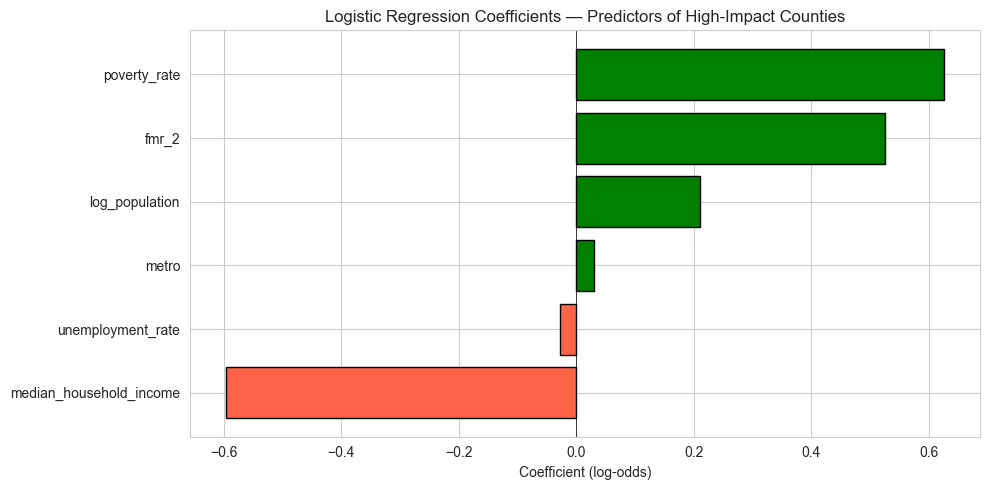

Coefficient values:
  median_household_income        -0.5966  ↓ disaster likelihood
  unemployment_rate              -0.0273  ↓ disaster likelihood
  metro                          +0.0296  ↑ disaster likelihood
  log_population                 +0.2110  ↑ disaster likelihood
  fmr_2                          +0.5256  ↑ disaster likelihood
  poverty_rate                   +0.6261  ↑ disaster likelihood


In [18]:
# Logistic regression coefficients represent the change in log-odds of being
# "high impact" for a one-standard-deviation increase in each feature.

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if c > 0 else 'tomato' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression Coefficients — Predictors of High-Impact Counties')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Coefficient values:')
for _, row in coef_df.iterrows():
    direction = '↑' if row['coefficient'] > 0 else '↓'
    print(f"  {row['feature']:30s} {row['coefficient']:+.4f}  {direction} disaster likelihood")

Now the model perfectly tells us how well the model classifies. However, not why it is. So now, it still a black box performance number in term of its parameterization. So now we want to know which features are actually driving this prediction capacity of this model?

Let take a look at its coefficient to understand this. The coefficients tell us the direction and magnitude of each feature's contribution to the model final output. So because the feature has been standardized, the each coefficient magnitude is called the length bar away from zero. So a one standard deviation increase in that feature changes the log odds of being high impact by the amount of that coefficient and vice versa

Now that we understand how to interpret and why looking at the coefficient, what does it tell us?

From the graph and numerical, the strongest predictors of high impact counties are higher poverty rate (+0.63) and fair market rent (+0.53) increasing disaster likelihood. On the other hand, higher median household income (-0.60) telling us that higher income will decreasing the impact of disaster (log odd wise). This is consistent with the OLS story.
    - Remember back in OLS, poverty_rate, fmr_2, and median_household_income were the only statisitcally significant coefficient and unemployment_rate and metro were not significant, as you see a small contribution to log odd in term of coefficient magnitude, same story (coin), differnet side of the coin!



## 7. Model 3: Decision Tree Classifier

Now that we see, logistic regression told us what predicts disasters likelihood and how confidently we are (probability wise). But note that the coefficients are in log odds. So we need a statisitical literacy to interpret them. Let think about decision tree. We want to ask, can we express the same findings as a simple flowchart that anyone can follow from the top down? For example, if poverty rate is above X and income is below Y, classify as high-impact? Without audience not knowing log-odds at all.

So keep this in mind, we are moving from statistical inference to a more human readable decision tree, trading off some of the mathematical rigor for interpretability. Paradoxically enough, decision tree can let us capture non linear relationships and feature interactions that logistic regression linear boudary might miss. This way, using both LR and decision tree, we can use as a communication tool and a model checking on whether linearity is a good, reasonable assumption.

In [20]:
# We use UNSCALED features here so the split thresholds are in original units
# (e.g., "median_household_income <= 55,000" instead of "feature_2 <= -0.41").
# Decision trees do not require feature scaling — they split on rank order.
#
# max_depth=4 and min_samples_leaf=50 keep the tree small and interpretable.
# A deeper tree would overfit to the training data.

tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)
tree.fit(X_train, y_cls_train)  # unscaled features

# predictions
y_tree_pred = tree.predict(X_test)
y_tree_prob = tree.predict_proba(X_test)[:, 1]

print('Classification Report — Decision Tree (Test Set)')
print(classification_report(y_cls_test, y_tree_pred, target_names=['Low Impact', 'High Impact']))

print(f'Accuracy:  {accuracy_score(y_cls_test, y_tree_pred):.3f}')
print(f'AUC-ROC:   {roc_auc_score(y_cls_test, y_tree_prob):.3f}')

Classification Report — Decision Tree (Test Set)
              precision    recall  f1-score   support

  Low Impact       0.65      0.71      0.68       329
 High Impact       0.66      0.60      0.63       314

    accuracy                           0.66       643
   macro avg       0.66      0.66      0.65       643
weighted avg       0.66      0.66      0.66       643

Accuracy:  0.656
AUC-ROC:   0.700


### Taking a look at the tree visualization!

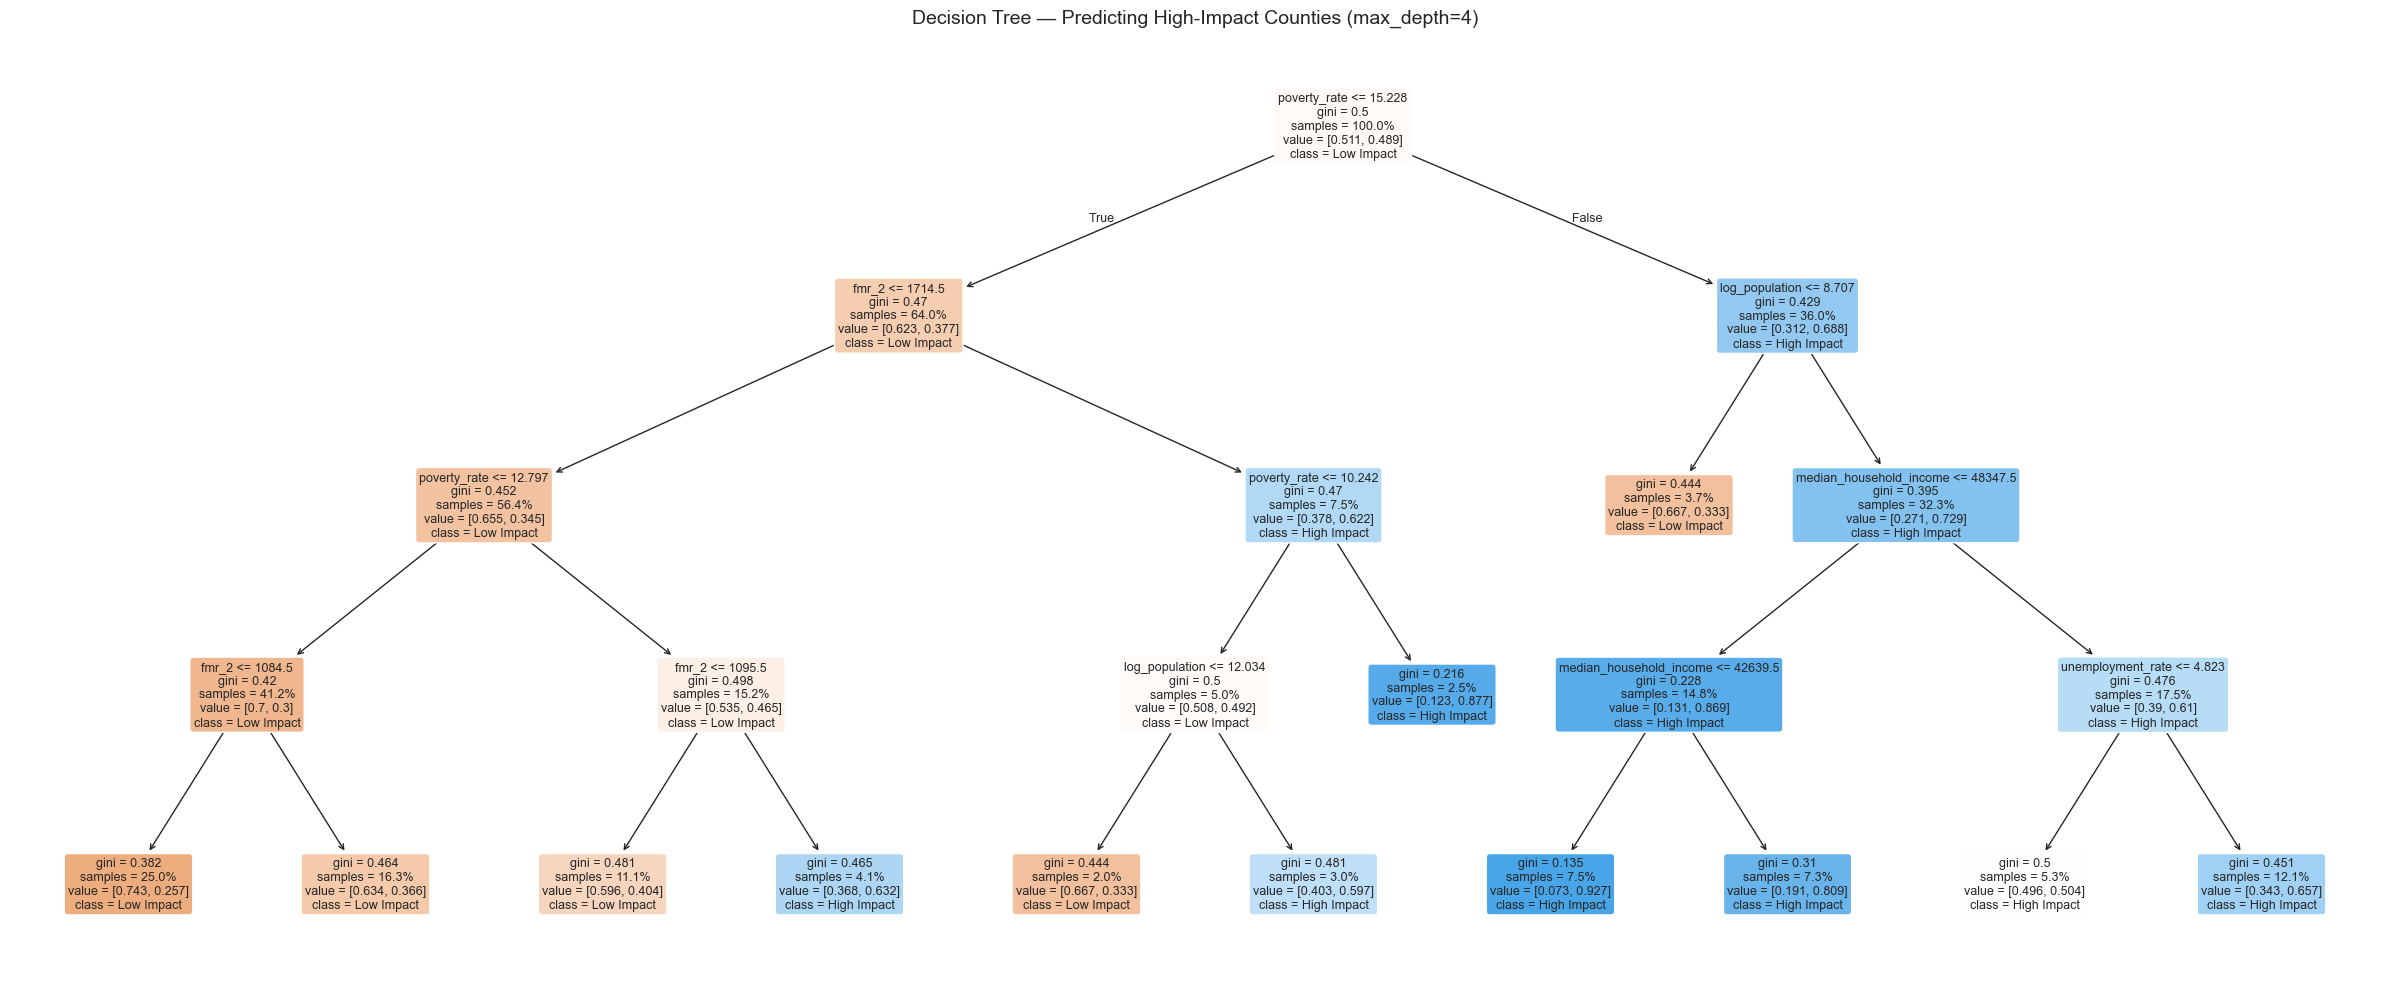

In [22]:

# The decision tree can be visualized as a flowchart — this is its main advantage
# over logistic regression. Each node shows the split rule, Gini impurity,
# sample count, and class distribution.

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    tree,
    feature_names=feature_cols,
    class_names=['Low Impact', 'High Impact'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    proportion=True
)
ax.set_title('Decision Tree — Predicting High-Impact Counties (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()

Looking at the confusion matrix table and the tree itself, notice that the same pattern converge to the same story with OLS and LR that poverty rate i the first and most important split at the root and counties with high poverty, high fair market rent, and low income consistently branch toward high impact. Why is that?

Well, because these three features capture the same underlying reality, let step back and think about this intuitively, for economically vulenrable counties (poor, expensive housing, and low income) they are tend to cluster in geographically high risk regions like the Gulf Coast and tornado alley, so the signal is real and consistent regardless of which model or method is being used to detect it!

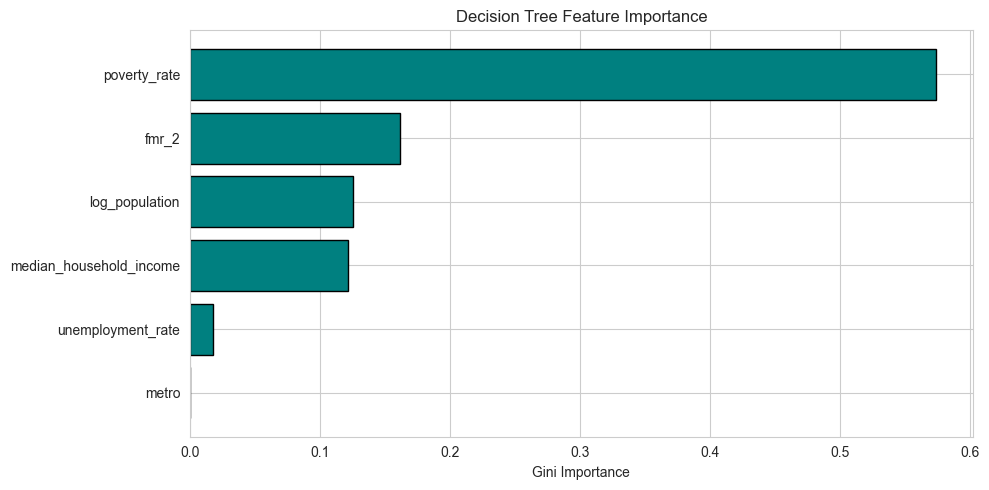

Feature importance values:
  poverty_rate                   0.5733
  fmr_2                          0.1615
  log_population                 0.1255
  median_household_income        0.1216
  unemployment_rate              0.0180
  metro                          0.0000


In [23]:
# Feature Importance (Gini Importance)
# Gini importance measures how much each feature contributes to reducing
# impurity across all splits in the tree. Higher = more important for classification.

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='teal', edgecolor='black')
ax.set_xlabel('Gini Importance')
ax.set_title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

print('Feature importance values:')
for _, row in importance_df.sort_values('importance', ascending=False).iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

Though for reader, the tree above is a bit hard to visualize with all the rules despite that it is practically readable, we want to introduce gini imporant such that we want it to collapses the entire tree into a single ranked bar chart, which would give the same features that drives the outcome that the LR coefficients had told us, but now from the tree perspective.

Just a quick note on the gini important meaning. So at each node, if we split a node 50/50, the node is is .5 gini, meaning it is maximally impure, and with node with all one class is perfectly pure. With that being said, as we split more node, it reduces the impurity right? So gini importancefor a feature is simply the total impurity reduction that feature is responsible for across all splits in the tree.

Now that we get the theory out the way, look at the bar graph and the numerical table, we see that poverty rate dominates with a gini importance of 0.57, what does this tell us? This means that poverter as a feature alone responsible for over half of all impurity reduction in the tree gini importance. That means if we sum across all those splits, poverty_rate contributed 57 percent of the total purity gain across the entire tree, meaning this feature seperated high impact from low impact counties more effectively than all other five feature combined (as the other five features are contributed modestly). But bottom line is that this perfectly mirror the same story with OLS and logistic regression.



## 8. Model Comparison

In [ ]:
# lets printout a Side-by-Side Metrics Table
# taking a look at what we have so far in term of classification performance
# for both logistic regression and decision tree on the test set.

comparison = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_cls_test, y_cls_pred),
        precision_score(y_cls_test, y_cls_pred),
        recall_score(y_cls_test, y_cls_pred),
        f1_score(y_cls_test, y_cls_pred),
        roc_auc_score(y_cls_test, y_cls_prob)
    ],
    'Decision Tree': [
        accuracy_score(y_cls_test, y_tree_pred),
        precision_score(y_cls_test, y_tree_pred),
        recall_score(y_cls_test, y_tree_pred),
        f1_score(y_cls_test, y_tree_pred),
        roc_auc_score(y_cls_test, y_tree_prob)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])

print('Classification Model Comparison (Test Set)')
print(comparison.round(3).to_string())

Classification Model Comparison (Test Set)
           Logistic Regression  Decision Tree
Accuracy                 0.656          0.656
Precision                0.654          0.663
Recall                   0.627          0.602
F1-Score                 0.641          0.631
AUC-ROC                  0.711          0.700


Nothing surprised here, as we thoroughly and rigorously analyze previously, both models perform nearly identically. This tells us there are some ceiling fundamentally from our data itself (missing geography feature), not the choice of modeling. So switching to a more complex algorithm won't help until we add geographic features.

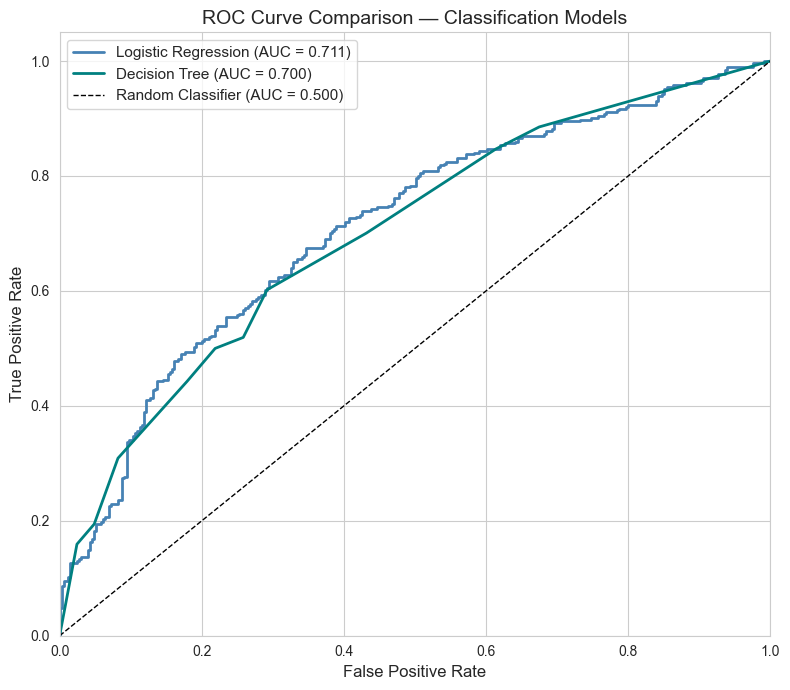

In [ ]:
# let's observe the Overlaid ROC Curves between our 
# two classification models to see if one has better discriminative
# ability than the other across all thresholds.

fig, ax = plt.subplots(figsize=(8, 7))

# logistic regression
fpr_lr, tpr_lr, _ = roc_curve(y_cls_test, y_cls_prob)
auc_lr = roc_auc_score(y_cls_test, y_cls_prob)
ax.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# decision tree
fpr_dt, tpr_dt, _ = roc_curve(y_cls_test, y_tree_prob)
auc_dt = roc_auc_score(y_cls_test, y_tree_prob)
ax.plot(fpr_dt, tpr_dt, color='teal', linewidth=2,
        label=f'Decision Tree (AUC = {auc_dt:.3f})')

# random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — Classification Models', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Well same here, nothing surprised, both curves track nearly on top of each other and bow above the random baseline. Further confirmed that the bottleneck is pattern in term of feature regarding geographic feature.



## 9. State Fixed Effects: Geography vs. Demographics

Well that being said, we kept repeating ourself here that geographic feature are needed to improve m|odeling. But this is just speculation from previous analysis. Let actually test this hypothesis, shall we?

But wait, what does state fixed effect even mean in term of data, specifically , features?

When we say state fixed effect, we mean that adding a dummy variable 0/1 for each state, so the model can learn a separate baseline disaster level for every state. By doing this we are efectively encode into our current data a specific pattern that asks: among counties within the same state, do demographics still predict disaster frequency?

Askking this we can ensure that we design our features that not only letting geography silently drive the results.

In [30]:
# OLS with State Fixed Effects
# This is the key test: if adding state dummy variables dramatically increases R²,
# it means geography ("where you are") matters far more than demographics ("who you are").
#
# Fixed effects absorb all between-state variation. What remains is within-state
# variation: among counties in the SAME state, do demographics still predict disasters?

# merge state back into the modeling dataframe
df_fe = df_model.copy()

# create state dummy variables (drop_first=True avoids the dummy variable trap)
state_dummies = pd.get_dummies(df_fe['state_abbr'], prefix='state', drop_first=True, dtype=float)

# build the two design matrices
X_demo = df_fe[feature_cols]  # demographics only
X_demo_state = pd.concat([df_fe[feature_cols], state_dummies], axis=1)  # demographics + state FE

y = df_fe['log_disasters']

# fit both models on the full dataset (this is for comparison, not prediction)
X_demo_c = sm.add_constant(X_demo)
X_demo_state_c = sm.add_constant(X_demo_state)

ols_demo = sm.OLS(y, X_demo_c).fit()
ols_state = sm.OLS(y, X_demo_state_c).fit()

print(f'Model Comparison: Demographics Only vs. Demographics + State Fixed Effects')
print(f'Demographics only:         R² = {ols_demo.rsquared:.4f}   Adj. R² = {ols_demo.rsquared_adj:.4f}   AIC = {ols_demo.aic:.1f}')
print(f'Demographics + State FE:   R² = {ols_state.rsquared:.4f}   Adj. R² = {ols_state.rsquared_adj:.4f}   AIC = {ols_state.aic:.1f}')

print(f'R² improvement from state FE: +{ols_state.rsquared - ols_demo.rsquared:.4f}')
print(f'Number of state dummies added: {len(state_dummies.columns)}')

Model Comparison: Demographics Only vs. Demographics + State Fixed Effects
Demographics only:         R² = 0.1666   Adj. R² = 0.1650   AIC = 4035.4
Demographics + State FE:   R² = 0.7420   Adj. R² = 0.7374   AIC = 368.6
R² improvement from state FE: +0.5755
Number of state dummies added: 50


Not to our surprise, we actually expected this the whole time, r squared jump from 0.167 to 0.742. That is a 57.5 percentage point jump. Definitely confirm us that geography, not demographics, is the dominant driver of disaster frequency, not that we saying it is completely useless to include but in fact our six demographic features were only explaining the leftover within state variation all along.

Now let double check its how demographic coefficient changes as we added new feature engineering data.

In [32]:
# How do demographic coefficients change with state fixed effects?
# If a coefficient changes sign or loses significance when states are added,
# it means the original association was confounded by geography.

coef_comparison = pd.DataFrame({
    'Demo Only (coef)': ols_demo.params[feature_cols],
    'Demo Only (p-val)': ols_demo.pvalues[feature_cols],
    'With State FE (coef)': ols_state.params[feature_cols],
    'With State FE (p-val)': ols_state.pvalues[feature_cols],
}).round(4)

# add significance flags
coef_comparison['Demo sig?'] = coef_comparison['Demo Only (p-val)'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)
coef_comparison['FE sig?'] = coef_comparison['With State FE (p-val)'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)

print('Demographic Coefficients: With vs. Without State Fixed Effects')
print(coef_comparison.to_string())
print('\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant')

Demographic Coefficients: With vs. Without State Fixed Effects
                         Demo Only (coef)  Demo Only (p-val)  With State FE (coef)  With State FE (p-val) Demo sig? FE sig?
log_population                     0.0273             0.0001                0.0266                 0.0000       ***     ***
median_household_income           -0.0000             0.0000               -0.0000                 0.0139       ***       *
poverty_rate                       0.0147             0.0000                0.0003                 0.8222       ***      ns
unemployment_rate                  0.0019             0.6184                0.0029                 0.1793        ns      ns
fmr_2                              0.0003             0.0000                0.0000                 0.3223       ***      ns
metro                              0.0311             0.1432               -0.0313                 0.0174        ns       *

Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant

So after adding 50 columns into modeling, turned out poverty_rate and fmr_2, our two previous two strongest demographic predictors now became  statistically insignificant the moment we added state in to controlled for. What i meant by controlled for is that as we added state dummies, we are holding geography constant and demographic and housing features became insignificant in modeling, we can confirmed that they are confounded by geography all along; so poor, high rent counties aren't disaster prone because their demograpghics, they just happen to be located in high disaster states.


## 10. Summary and Conclusions

Let wrap this up, I think we have enough evidence to conclude. Let's print out what we have thus far.

In [34]:
# Final Performance Summary

summary = pd.DataFrame({
    'Model': [
        'OLS Linear Regression',
        'OLS + State Fixed Effects',
        'Logistic Regression',
        'Decision Tree (depth=4)'
    ],
    'Task': ['Regression', 'Regression', 'Classification', 'Classification'],
    'Key Metric': [
        f'R² = {ols_demo.rsquared:.3f}',
        f'R² = {ols_state.rsquared:.3f}',
        f'AUC = {roc_auc_score(y_cls_test, y_cls_prob):.3f}',
        f'AUC = {roc_auc_score(y_cls_test, y_tree_prob):.3f}'
    ],
    'Strengths': [
        'Full statistical inference (p-values, CI)',
        'Controls for geography; isolates demographics',
        'Probability outputs; coefficient interpretation',
        'Visual decision rules; captures non-linearity'
    ]
})

print('Model Performance Summary')
print(summary.to_string(index=False))

Model Performance Summary
                    Model           Task  Key Metric                                       Strengths
    OLS Linear Regression     Regression  R² = 0.167       Full statistical inference (p-values, CI)
OLS + State Fixed Effects     Regression  R² = 0.742   Controls for geography; isolates demographics
      Logistic Regression Classification AUC = 0.711 Probability outputs; coefficient interpretation
  Decision Tree (depth=4) Classification AUC = 0.700   Visual decision rules; captures non-linearity


In short, OLS with state fixed effect is our headline finding that demographic alone are weak predictors but once geography is controlled for the model explains 74 percent of variance. Both classification model hover around AUC = .7 and so each serving different purpose. For LR, we interpret the coefficients and for decision tree we it is more stakeholder or non technical friendly with decision rules.

Just a subtle note and more nuance to acknowledge is that we didn't include state fix effect dummies variables because without OLS, we already confirm our hypothesis. Therefore, no need for us to further included our computation for LR and decision because it would give us the same answer, hypothesis-wise.

## In Conclusion

### Let's racap what we found in this notebook:

- We learned that demographics alone are weak predictors of disaster frequency because the fact that our OLS model only explains only 16.7 percent of the variance. This confirmed us what we kept suspecting throughout EDA that EDA frequency is primarily a geography story that not a demographics ones.
- We confirmed that state fixed effects proved this. Once we controlled for geography by adding state dummies, our R square jumped from 0.167 to 0.742. That is the smoking gun that we tested where a county is located matters far more than how poor or how urban it is.
- Our classification model also tell us the same story. As both of logistic regression and decision tree lands around AUC = 0.70. It is better than random in term of log odds (or you can interpret it as probability), but still not great. But yes, demographic carry some signal, just not enough on their own.

- Throughout this journey, the decision tree to us were the most honest communicator. As it give us the same findings as OLS and logistic regression, but in plain English wise, its actual thresholds anyone can follow without needing to understand log odds or p values; for example if you were present this your boss, stakeholders or teaching your friends your research project.

### Otherwise, there are some limitations:
- Despite in this story, we found out that geography were confounding demographic and housing data, we can't still clear say that geography causes, but more like correlations. So bottom line is that we can fairly say that poverty does not cause disasters but rather the fact that they tend to co-locate in the same high risk geographies.
- We also only look at a single snapshot in time. So demographics and disaster might shift and this analysis would not capture that.
- Remember the 80 counties that were dropped? Yes, so these are systematically the most disaster-prone counties, for example territories frontier like Alaska, that our models don't speak to them
- Lastly, only six feature, that were use to study disaster outcome. Intuitively, we actually need more feature like elevation, coastal proximity, historical climate data, as these would move the needle but were outside our database scope.

### Those we need to include special thanks to our group work on database engineering pipeline that made all of this possible!

So every model here run on the analysis_ready VIEW our ETL pipeline built. Without referential integrity on FIPS codes, our state fixed effects would be contaminated. Imaging without the LEFT JOIN design, those 80 missing counties would have silently disappeared instead of being explicity acknowledged for. Bottom line is that, modelling without database designing and pipelining are only as trustworthy as the data underneath what structure them, therefore, that start with a well designed database is a must before even thinking out analysis, let alone modeling.